Linear Regression: The objective is to model and predict the AI Risk Score as a continuous dependent variable, while identifying the key independent variables that significantly increase or decrease the score.

In [7]:
#Import Relevant Python Libaries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
#Import DataSet 
df = pd.read_csv(r"C:\Users\edwin\Desktop\SJU Classes\Grad School\ML\preprocessed_data.csv")
df.head()
df.info()
df.describe()



<class 'pandas.DataFrame'>
RangeIndex: 12343 entries, 0 to 12342
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   year                             12343 non-null  float64
 1   salary                           12343 non-null  float64
 2   ai_risk_score                    12343 non-null  float64
 3   skill_demand_score               12343 non-null  float64
 4   job_openings                     12343 non-null  float64
 5   job_survival_class               12343 non-null  float64
 6   job_title_Business Analyst       12343 non-null  bool   
 7   job_title_Cloud Engineer         12343 non-null  bool   
 8   job_title_Cybersecurity Analyst  12343 non-null  bool   
 9   job_title_Data Analyst           12343 non-null  bool   
 10  job_title_Data Scientist         12343 non-null  bool   
 11  job_title_DevOps Engineer        12343 non-null  bool   
 12  job_title_ML Engineer        

,year,salary,ai_risk_score,skill_demand_score,job_openings,job_survival_class
count,1.234300e+04,1.234300e+04,1.234300e+04,1.234300e+04,1.234300e+04,1.234300e+04
mean,-6.114709e-15,1.950064e-16,-2.486871e-16,-4.864365e-16,-6.461834e-17,-1.735629e-16
std,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00
min,-1.659582e+00,-1.732940e+00,-1.845962e+00,-1.694092e+00,-1.710238e+00,-1.989783e+00
25%,-8.342909e-01,-7.426586e-01,-7.252240e-01,-8.232445e-01,-8.635798e-01,-4.709275e-01
50%,-8.999772e-03,-1.616377e-01,-1.915393e-01,-3.948199e-02,-2.313480e-02,-4.709275e-01
75%,8.162913e-01,6.175101e-01,5.022508e-01,8.313653e-01,8.626051e-01,1.047928e+00
max,1.641582e+00,2.657763e+00,2.343463e+00,1.702213e+00,1.749263e+00,1.047928e+00


We Imorted the preprocesed data which means: 
1. All Categorical variables are encoded: Indiated by the True and False 
2. No Missing Values 
3. Data is Standardize: Indicated by mean of 0 and Standard deviation of 1. 

Data Cleaning: 
1. Reverse Standardization for your y value (ai risk score factor)


In [24]:
#Import Original Data

ogdf = pd.read_csv(r"C:\Users\edwin\.cache\kagglehub\datasets\shree0910\ai-job-risk-and-salary-dataset-20152035\versions\2\Future of Jobs AI Dataset.csv")
ogdf.head()

#Merge AI Risk Score
df["ai_risk_score"] = ogdf["ai_risk_score"]

df.head()


,year,salary,ai_risk_score,skill_demand_score,job_openings,job_survival_class,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,...,primary_skill_Excel,primary_skill_Java,primary_skill_Python,primary_skill_SQL,primary_skill_Security,primary_skill_Strategy,salary_bucket_Low,salary_bucket_Medium,ai_risk_category_Low Risk,ai_risk_category_Medium Risk
0,-0.504174,1.560533,0.32,0.744281,0.983874,1.047928,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,1.146408,-0.742691,0.52,0.047603,-1.268021,-0.470928,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
2,-1.659582,-0.579291,0.25,-0.823245,-0.159690,-0.470928,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
3,1.476524,-1.283661,0.44,1.353874,-0.579030,-0.470928,False,False,False,False,...,False,False,True,False,False,False,False,True,False,True
4,1.641582,-0.931689,0.75,-1.607007,-1.538591,-1.989783,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False


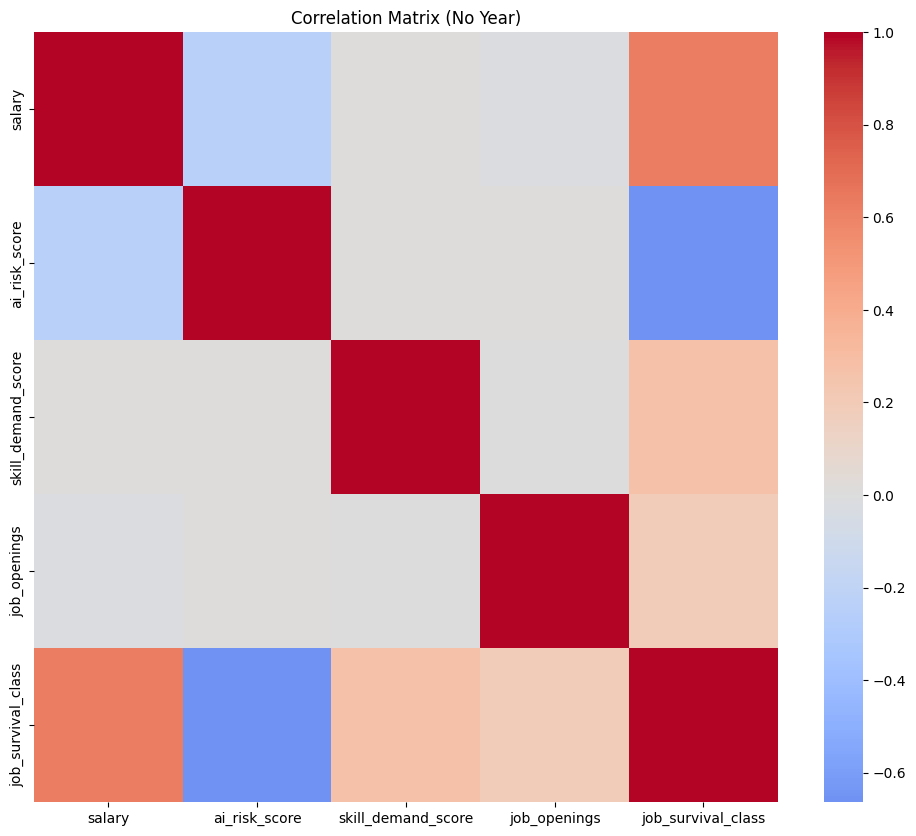

In [26]:
#Correlation Matrix: Linear Regresion Viable

df_numeric = df.select_dtypes(include='number').drop(columns=['year'])

corr = df_numeric.corr()


plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (No Year)")
plt.show()

The correlation matrix above illustrates the relationships between key numerical variables: salary, AI risk score, skill demand score, job openings, and job survival class.

Key Findings:
Salary and Job Survival Class show a moderate positive correlation, suggesting that higher-paying jobs tend to have greater long-term stability and survivability.
AI Risk Score and Job Survival Class exhibit a moderate negative correlation, indicating that jobs with higher susceptibility to AI automation are less likely to survive in the long term.
Skill Demand Score and Job Survival Class have a positive relationship, implying that jobs requiring in-demand skills are more resilient and less likely to be displaced.
Job Openings and Job Survival Class also show a positive correlation, suggesting that jobs with more available opportunities tend to be more stable and sustainable.
Salary and AI Risk Score display a negative correlation, indicating that higher-paying roles are generally less exposed to AI-related risks.
The relationships between skill demand score, job openings, and AI risk score appear relatively weak, suggesting limited direct linear association among these variables.
Overall Interpretation:

The results suggest that job stability is positively influenced by higher salaries, greater skill demand, and more job openings, while AI risk negatively impacts job survival. These findings align with expectations, as roles that require specialized skills and offer higher compensation are typically more resistant to automation.